In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

### Loading the data

In [2]:
df = pd.read_csv(r'C:\Users\Vaibhav\OneDrive\문서\Desktop\Python\ecommerce_transactions.csv')
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (34099, 20)


,OrderID,CustomerID,OrderDate,Gender,Age,City,State,Region,CityTier,SignupDate,ProductCategory,Quantity,UnitPrice,DiscountPercent,DiscountAmount,GrossAmount,NetAmount,PaymentMode,OrderStatus,Rating
0,ORD103082,CUST00283,2023-01-01,Male,30,Kochi,Kerala,South,3,2023-01-01,Grocery,1,499.0,5,24.95,499.0,474.05,UPI,Delivered,2.0
1,ORD133440,CUST02964,2023-01-13,Male,18,Delhi,Delhi,North,1,2023-01-10,Mobiles & Accessories,1,41449.0,0,0.00,41449.0,41449.00,Net Banking,Delivered,4.0
2,ORD133439,CUST02964,2023-01-13,Male,18,Delhi,Delhi,North,1,2023-01-10,Fashion,1,4999.0,30,1499.70,4999.0,3499.30,UPI,Delivered,2.0
3,ORD133438,CUST02964,2023-01-13,Male,18,Delhi,Delhi,North,1,2023-01-10,Fashion,1,2769.0,0,0.00,2769.0,2769.00,Cash on Delivery,Delivered,3.0
4,ORD133437,CUST02964,2023-01-13,Male,18,Delhi,Delhi,North,1,2023-01-10,Fashion,1,4999.0,20,999.80,4999.0,3999.20,Cash on Delivery,Delivered,3.0


### 1. Data Cleaning

In [3]:
# Standardize inconsistent text 

df["ProductCategory"] = df["ProductCategory"].str.strip().str.title()
df["Gender"] = df["Gender"].str.strip().str.title()
df["City"] = df["City"].str.strip().str.title()
df["State"] = df["State"].str.strip().str.title()
df["Region"] = df["Region"].str.strip().str.title()
df["PaymentMode"] = df["PaymentMode"].str.strip()
df["OrderStatus"] = df["OrderStatus"].str.strip()

In [4]:
# Fixing datatypes and removing duplicates

df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")
df["SignupDate"] = pd.to_datetime(df["SignupDate"], errors="coerce")

before = len(df)
df = df.drop_duplicates(subset=["OrderID"]).drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 271 duplicate rows


In [6]:
# Missing values

df["PaymentMode"] = df["PaymentMode"].fillna("Unknown")   # ~1% missing -> bucket as Unknown
df["RatingGiven"] = df["Rating"].notna().astype(int)

# Negative value data errors

neg_mask = df["Quantity"] < 0
n_neg = neg_mask.sum()
df["Quantity"] = df["Quantity"].abs()
df.loc[neg_mask, "GrossAmount"] = df.loc[neg_mask, "Quantity"] * df.loc[neg_mask, "UnitPrice"]
df.loc[neg_mask, "DiscountAmount"] = df.loc[neg_mask, "GrossAmount"] * df.loc[neg_mask, "DiscountPercent"] / 100
df.loc[neg_mask, "NetAmount"] = df.loc[neg_mask, "GrossAmount"] - df.loc[neg_mask, "DiscountAmount"]
print(f"Corrected {n_neg} negative-quantity data-entry errors")

# cap netamount outliers ( for modeling )

q1, q3 = df["NetAmount"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = max(q1 - 1.5 * iqr, 0), q3 + 1.5 * iqr
df["NetAmount_capped"] = df["NetAmount"].clip(lower=lower, upper=upper)

Corrected 0 negative-quantity data-entry errors


### 2. Feature engineering

In [7]:
df["OrderYear"] = df["OrderDate"].dt.year
df["OrderMonth"] = df["OrderDate"].dt.to_period("M").astype(str)
df["OrderWeekday"] = df["OrderDate"].dt.day_name()
df["TenureDays"] = (df["OrderDate"] - df["SignupDate"]).dt.days
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 24, 34, 44, 54, 100],
                         labels=["<25", "25-34", "35-44", "45-54", "55+"])
df["IsReturnOrCancel"] = df["OrderStatus"].isin(["Returned", "Cancelled"]).astype(int)

# Simple, interpretable flag columns (avoid black-box encodings - a hiring
# manager should be able to read the columns and understand them immediately)
df["Gender_Male"] = (df["Gender"] == "Male").astype(int)
df["CityTier1"] = (df["CityTier"] == 1).astype(int)

print(f"\nFinal shape: {df.shape}")


Final shape: (33828, 30)


### 3. EDA

In [8]:
delivered = df[df["OrderStatus"] == "Delivered"]

total_revenue = delivered["NetAmount"].sum()
total_orders = delivered["OrderID"].nunique()
aov = delivered["NetAmount"].mean()
print(f"Total Net Revenue: Rs {total_revenue:,.0f}")
print(f"Total Delivered Orders: {total_orders:,}")
print(f"Average Order Value: Rs {aov:,.2f}")

Total Net Revenue: Rs 393,193,809
Total Delivered Orders: 30,241
Average Order Value: Rs 13,002.01


#### Monthly revenue Trend 

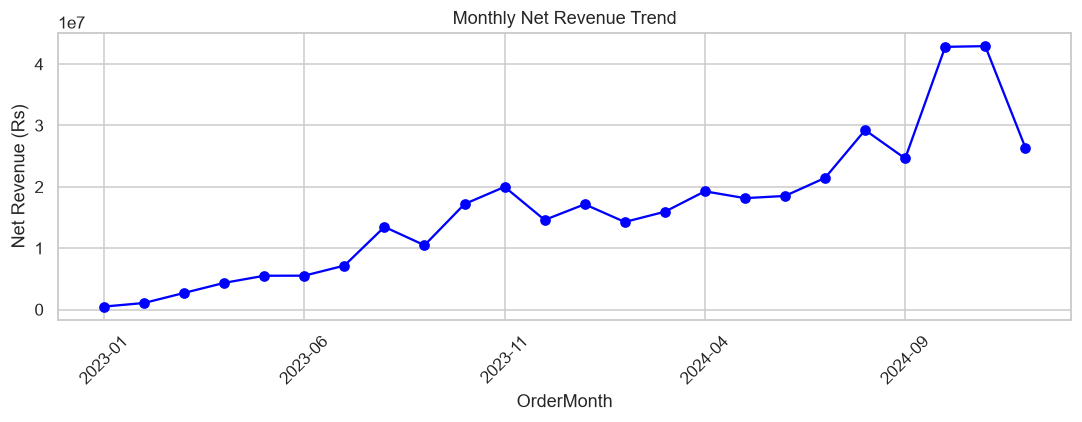

In [10]:
monthly_rev = delivered.groupby("OrderMonth")["NetAmount"].sum().sort_index()
plt.figure(figsize=(10, 4))
monthly_rev.plot(marker="o", color="Blue")
plt.title("Monthly Net Revenue Trend")
plt.ylabel("Net Revenue (Rs)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Order status split

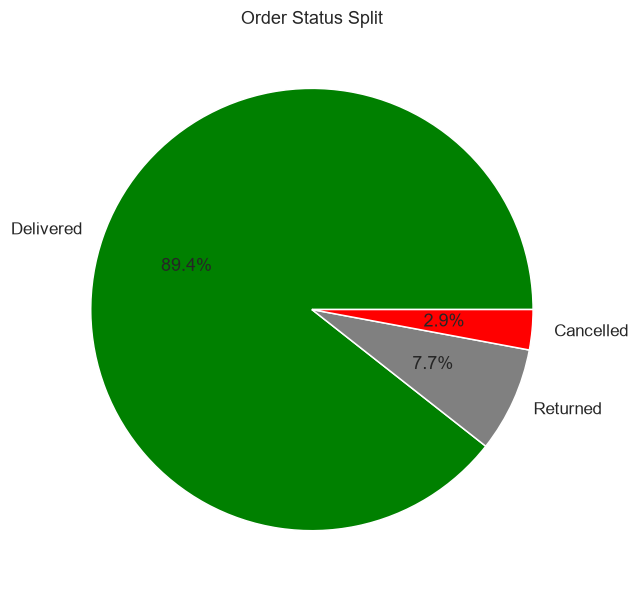

In [13]:
status_counts = df["OrderStatus"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
        colors=["Green", "grey", "Red"])
plt.title("Order Status Split")
plt.tight_layout()
plt.show()

#### Revenue by category

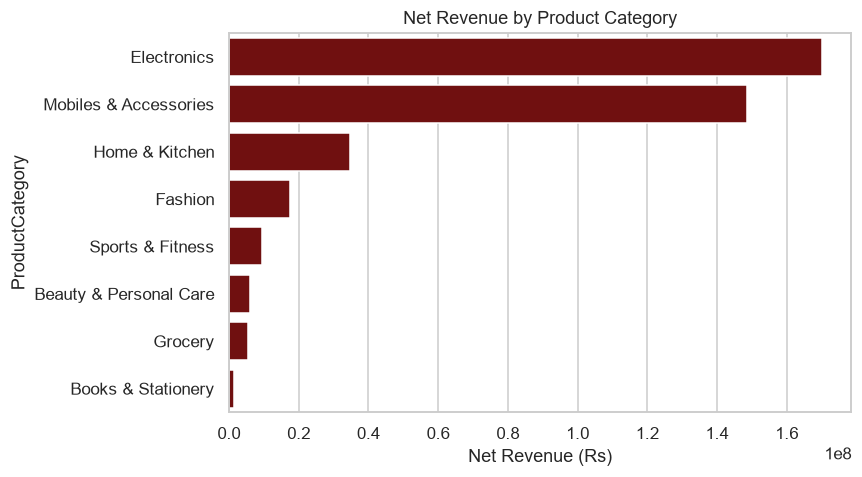

In [18]:
cat_rev = delivered.groupby("ProductCategory")["NetAmount"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4.5))
sns.barplot(x=cat_rev.values, y=cat_rev.index, color="maroon")
plt.title("Net Revenue by Product Category")
plt.xlabel("Net Revenue (Rs)")
plt.tight_layout()
plt.show()

#### Revenue by region and city tier


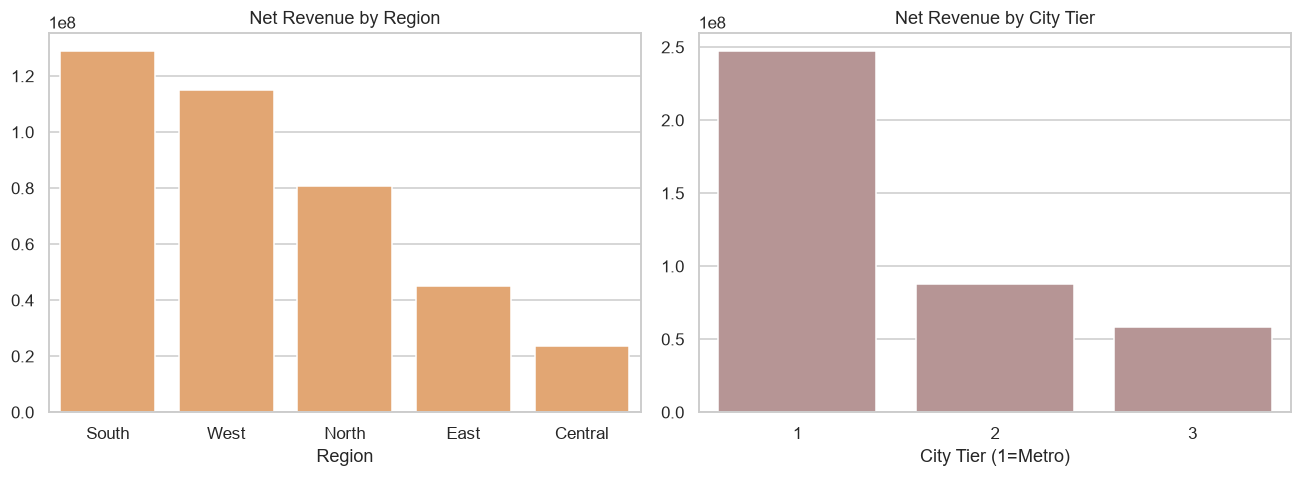

In [20]:
region_rev = delivered.groupby("Region")["NetAmount"].sum().sort_values(ascending=False)
tier_rev = delivered.groupby("CityTier")["NetAmount"].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=region_rev.index, y=region_rev.values, ax=axes[0], color="sandybrown")
axes[0].set_title("Net Revenue by Region")
sns.barplot(x=tier_rev.index, y=tier_rev.values, ax=axes[1], color="rosybrown")
axes[1].set_title("Net Revenue by City Tier")
axes[1].set_xlabel("City Tier (1=Metro)")
plt.tight_layout()
plt.show()

#### Customer demographics

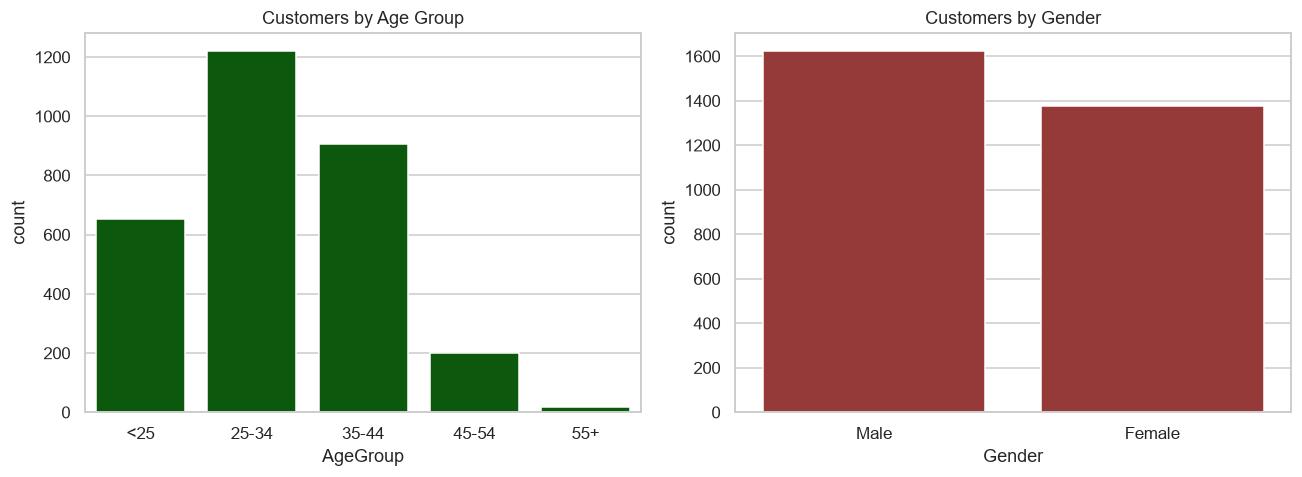

In [22]:
cust_demo = df.drop_duplicates("CustomerID")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=cust_demo, x="AgeGroup", order=["<25","25-34","35-44","45-54","55+"], ax=axes[0], color="darkgreen")
axes[0].set_title("Customers by Age Group")
sns.countplot(data=cust_demo, x="Gender", ax=axes[1], color="brown")
axes[1].set_title("Customers by Gender")
plt.tight_layout()
plt.show()

#### Repeat vs one time customers

Repeat customer share: 84.4%


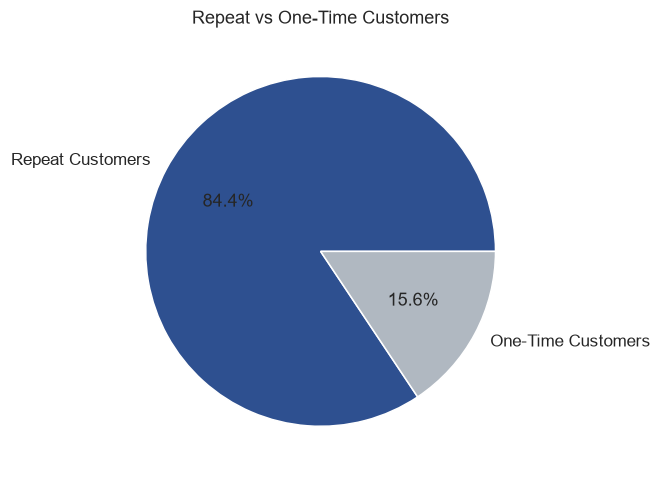

In [23]:
orders_per_cust = delivered.groupby("CustomerID")["OrderID"].nunique()
repeat_share = (orders_per_cust > 1).mean() * 100
print(f"Repeat customer share: {repeat_share:.1f}%")

plt.figure(figsize=(6, 6))
plt.pie([repeat_share, 100 - repeat_share], labels=["Repeat Customers", "One-Time Customers"],
        autopct="%1.1f%%", colors=["#2E5090", "#B0B8C1"])
plt.title("Repeat vs One-Time Customers")
plt.tight_layout()
plt.show()

#### Payment mode preference

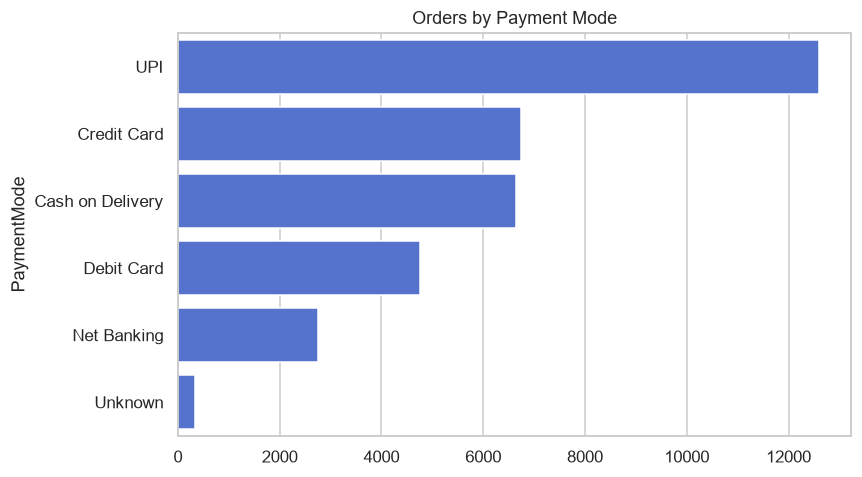

In [25]:
pay_counts = df["PaymentMode"].value_counts()
plt.figure(figsize=(8, 4.5))
sns.barplot(x=pay_counts.values, y=pay_counts.index, color="royalblue")
plt.title("Orders by Payment Mode")
plt.tight_layout()
plt.show()

#### Revenue by day of week 

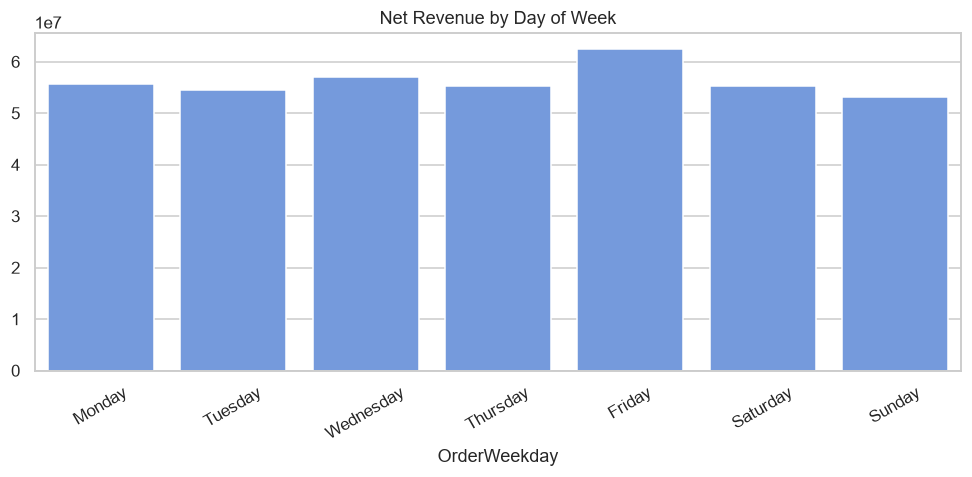

In [27]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
wd_rev = delivered.groupby("OrderWeekday")["NetAmount"].sum().reindex(weekday_order)
plt.figure(figsize=(9, 4.5))
sns.barplot(x=wd_rev.index, y=wd_rev.values, color="cornflowerblue")
plt.title("Net Revenue by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 4. RFM Analysis (Recency , Frequency , Monetary )

In [28]:
snapshot_date = df["OrderDate"].max() + pd.Timedelta(days=1)

rfm = delivered.groupby("CustomerID").agg(
    Recency=("OrderDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("OrderID", "nunique"),
    Monetary=("NetAmount", "sum"),
).reset_index()

# Customers with zero delivered orders still exist -> add them back
missing = set(df["CustomerID"].unique()) - set(rfm["CustomerID"])
if missing:
    filler = pd.DataFrame({
        "CustomerID": list(missing),
        "Recency": (df["OrderDate"].max() - df["OrderDate"].min()).days,
        "Frequency": 0, "Monetary": 0.0,
    })
    rfm = pd.concat([rfm, filler], ignore_index=True)

rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)


def segment_customer(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4: return "Champions"
    if r >= 3 and f >= 3 and m >= 3: return "Loyal Customers"
    if r >= 4 and f <= 2: return "New / Promising"
    if r <= 2 and f >= 3 and m >= 3: return "At Risk"
    if r <= 2 and f <= 2 and m >= 4: return "Cannot Lose Them"
    if r <= 2 and f <= 2 and m <= 2: return "Hibernating / Lost"
    return "Needs Attention"


rfm["RFM_Segment"] = rfm.apply(segment_customer, axis=1)
print(rfm["RFM_Segment"].value_counts())

RFM_Segment
At Risk               603
Needs Attention       541
Loyal Customers       512
Champions             500
Hibernating / Lost    445
New / Promising       383
Cannot Lose Them       16
Name: count, dtype: int64


### 5. K-Means Customer Segmentation

In [29]:
features = rfm[["Recency", "Frequency", "Monetary"]].copy()
features["Frequency_log"] = np.log1p(features["Frequency"])
features["Monetary_log"] = np.log1p(features["Monetary"])
X = features[["Recency", "Frequency_log", "Monetary_log"]]
X_scaled = StandardScaler().fit_transform(X)

#### Determine optimal K via Elbow + Silhouette

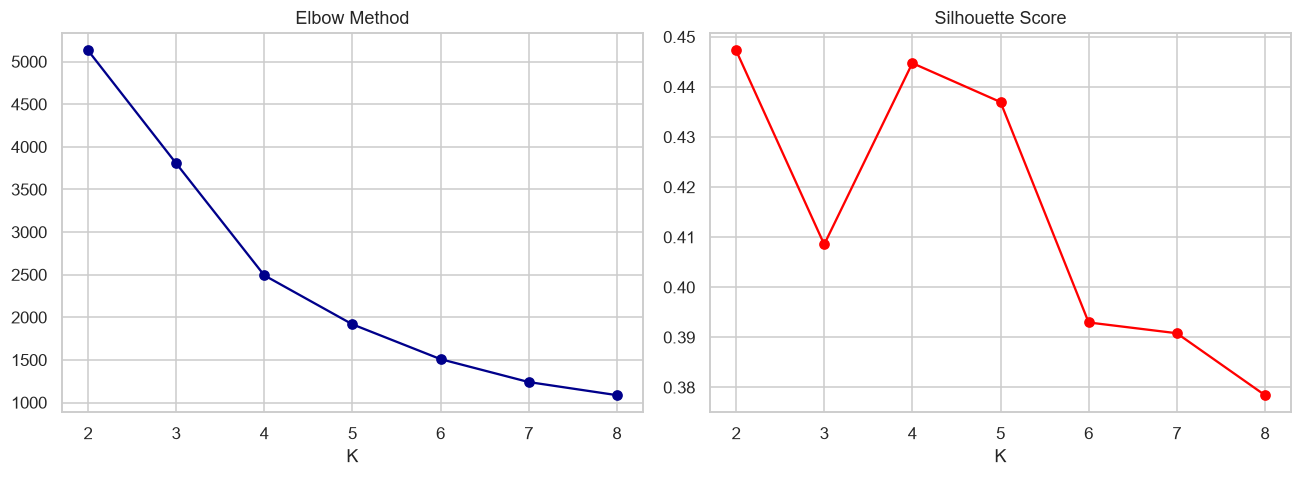

Segment_Label
High-Value Loyalists             1390
Steady / New Customers            858
At-Risk High Spenders             704
Dormant / Low-Value Customers      48
Name: count, dtype: int64


In [31]:
inertias, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(range(2, 9), inertias, marker="o", color="darkblue")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[1].plot(range(2, 9), sil_scores, marker="o", color="red")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
plt.tight_layout()
plt.show()

# K=4 chosen: elbow bends here, silhouette is competitive, and it maps
# cleanly onto 4 actionable business segments.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
label_map = {}
for cluster_id, row in profile.iterrows():
    if row["Recency"] <= profile["Recency"].median() and row["Monetary"] >= profile["Monetary"].median():
        label_map[cluster_id] = "High-Value Loyalists"
    elif row["Recency"] > profile["Recency"].median() and row["Monetary"] >= profile["Monetary"].median():
        label_map[cluster_id] = "At-Risk High Spenders"
    elif row["Recency"] <= profile["Recency"].median():
        label_map[cluster_id] = "Steady / New Customers"
    else:
        label_map[cluster_id] = "Dormant / Low-Value Customers"

rfm["Segment_Label"] = rfm["Cluster"].map(label_map)
print(rfm["Segment_Label"].value_counts())

### Visualize Clusters ( PCA Projection)

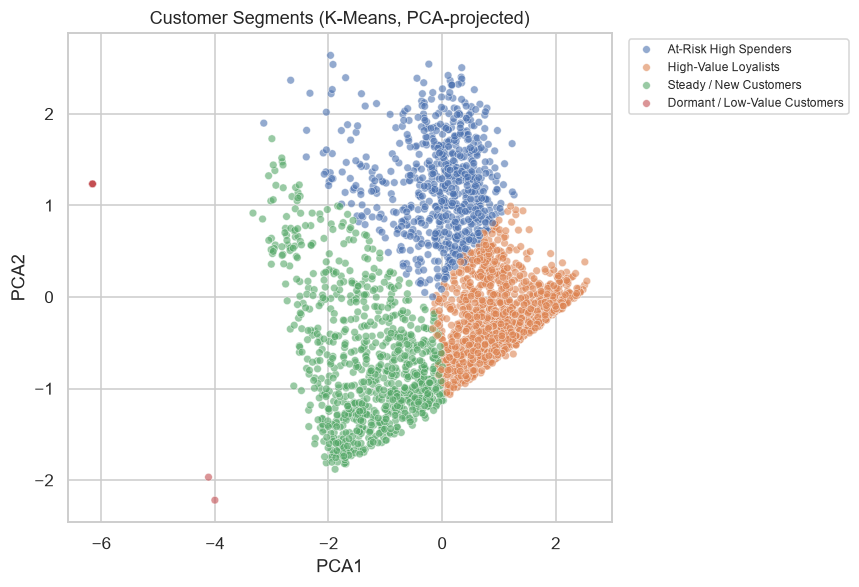

In [32]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
rfm["PCA1"], rfm["PCA2"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Segment_Label", alpha=0.6, s=25)
plt.title("Customer Segments (K-Means, PCA-projected)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Retention , Churn and Customer Lifetime Value (CLV)

In [33]:
clv = delivered.groupby("CustomerID").agg(
    TotalRevenue=("NetAmount", "sum"),
    TotalOrders=("OrderID", "nunique"),
    FirstPurchase=("OrderDate", "min"),
    LastPurchase=("OrderDate", "max"),
).reset_index()
clv["AvgOrderValue"] = clv["TotalRevenue"] / clv["TotalOrders"]

observation_window_days = (df["OrderDate"].max() - df["OrderDate"].min()).days
clv["PurchaseFreqPerYear"] = clv["TotalOrders"] / (observation_window_days / 365)
clv["Predicted_CLV_12mo"] = clv["AvgOrderValue"] * clv["PurchaseFreqPerYear"]

kpis = rfm[["CustomerID", "Recency", "Frequency", "Monetary", "RFM_Segment", "Segment_Label"]] \
    .merge(clv, on="CustomerID", how="left")
kpis[["TotalRevenue", "TotalOrders", "AvgOrderValue", "PurchaseFreqPerYear", "Predicted_CLV_12mo"]] = \
    kpis[["TotalRevenue", "TotalOrders", "AvgOrderValue", "PurchaseFreqPerYear", "Predicted_CLV_12mo"]].fillna(0)

CHURN_THRESHOLD_DAYS = 180
kpis["Churned"] = kpis["Recency"] > CHURN_THRESHOLD_DAYS
retention_rate = (1 - kpis["Churned"].mean()) * 100
print(f"Overall Retention Rate: {retention_rate:.1f}%")
print(f"Churn Rate: {100 - retention_rate:.1f}%")
print(f"Average Historical CLV: Rs {kpis['TotalRevenue'].mean():,.0f}")

kpis["ChurnRiskLevel"] = pd.cut(kpis["Recency"], bins=[-1, 90, 180, 365, 100000],
                                 labels=["Low Risk", "Medium Risk", "High Risk", "Churned"])

Overall Retention Rate: 63.6%
Churn Rate: 36.4%
Average Historical CLV: Rs 131,065


#### CLV by segment


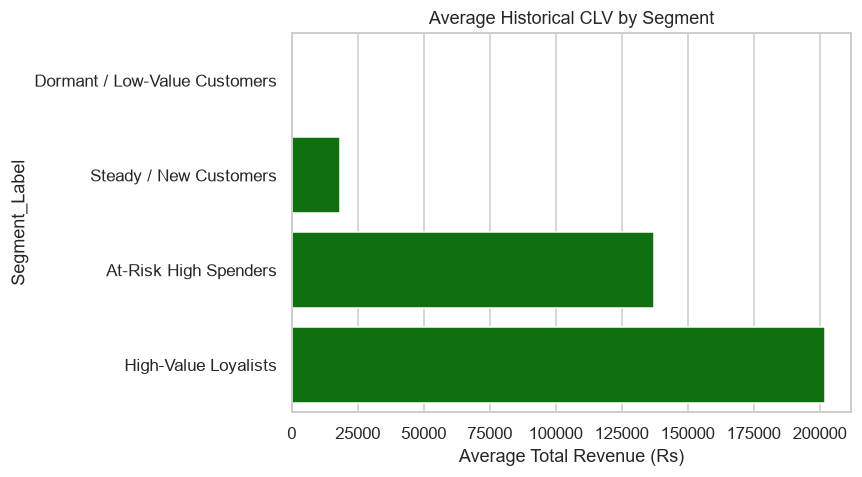

In [35]:
plt.figure(figsize=(8, 4.5))
clv_seg = kpis.groupby("Segment_Label")["TotalRevenue"].mean().sort_values()
sns.barplot(x=clv_seg.values, y=clv_seg.index, color="green")
plt.title("Average Historical CLV by Segment")
plt.xlabel("Average Total Revenue (Rs)")
plt.tight_layout()
plt.show()

#### Monthly cohort Retention

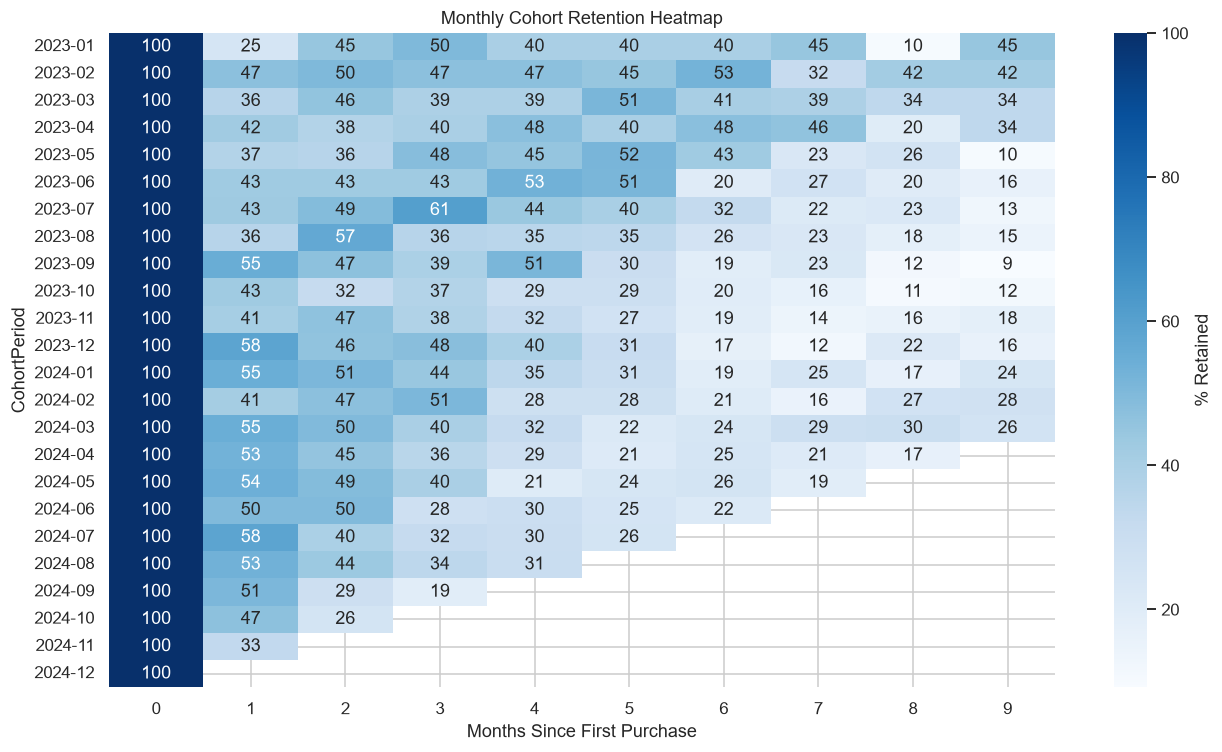

In [36]:
delivered = delivered.copy()
delivered["OrderPeriod"] = delivered["OrderDate"].dt.to_period("M")
first_purchase_period = delivered.groupby("CustomerID")["OrderDate"].min().dt.to_period("M")
delivered["CohortPeriod"] = delivered["CustomerID"].map(first_purchase_period)
delivered["CohortIndex"] = ((delivered["OrderPeriod"].dt.year - delivered["CohortPeriod"].dt.year) * 12
                             + (delivered["OrderPeriod"].dt.month - delivered["CohortPeriod"].dt.month))

cohort_data = delivered.groupby(["CohortPeriod", "CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortPeriod", columns="CohortIndex", values="CustomerID")
retention_matrix = cohort_pivot.divide(cohort_pivot.iloc[:, 0], axis=0) * 100

plt.figure(figsize=(12, 7))
sns.heatmap(retention_matrix.iloc[:, :10], annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% Retained"})
plt.title("Monthly Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.tight_layout()
plt.show()

## 6. Exporting SQL Tables


In [41]:
dim_customers = (
    df[["CustomerID", "Gender", "Age", "City", "State", "Region", "CityTier", "SignupDate"]]
    .drop_duplicates(subset=["CustomerID"])
    .sort_values("CustomerID")
    .rename(columns={
        "CustomerID": "customer_id", "Gender": "gender", "Age": "age", "City": "city",
        "State": "state", "Region": "region", "CityTier": "city_tier", "SignupDate": "signup_date",
    })
)

fact_orders = df[[
    "OrderID", "CustomerID", "OrderDate", "ProductCategory", "Quantity", "UnitPrice",
    "DiscountPercent", "DiscountAmount", "GrossAmount", "NetAmount", "PaymentMode",
    "OrderStatus", "Rating"
]].rename(columns={
    "OrderID": "order_id", "CustomerID": "customer_id", "OrderDate": "order_date",
    "ProductCategory": "product_category", "Quantity": "quantity", "UnitPrice": "unit_price",
    "DiscountPercent": "discount_percent", "DiscountAmount": "discount_amount",
    "GrossAmount": "gross_amount", "NetAmount": "net_amount", "PaymentMode": "payment_mode",
    "OrderStatus": "order_status", "Rating": "rating",
})

dim_customers.to_csv("dim_customers.csv", index=False)
fact_orders.to_csv("fact_orders.csv", index=False)

print(f"dim_customers: {dim_customers.shape}") # Customer table........
print(f"fact_orders  : {fact_orders.shape}")  # Transaction Table......
print("\nThese two files will be further load into PostgreSQL")

dim_customers: (3000, 8)
fact_orders  : (33828, 13)

These two files will be further load into PostgreSQL
